In [ ]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.chdir("/home/jupyter-yehlin/esm3_attention")

import sys
import numpy as np
import csv

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import pytorch_lightning as pl
from torchmetrics import MeanSquaredError, R2Score, SpearmanCorrCoef, PearsonCorrCoef
from omegaconf import OmegaConf

import pandas as pd
import pickle
import argparse
from math import isnan
from tqdm import tqdm
from dataclasses import dataclass
from typing import Optional


import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import random
from huggingface_hub import login
from esm.models.esm3 import ESM3
from esm.sdk.api import ESM3InferenceClient, ESMProtein, GenerationConfig
from esm.utils.structure.protein_chain import ProteinChain
import matplotlib.pyplot as plt
ALPHABET = 'ACDEFGHIKLMNPQRSTVWY'

os.chdir("/home/jupyter-yehlin/ESM3_SaProt_dG")
from config_esm3 import get_default_config, get_model_configs
from ESM3ABS import ESM3ABS, ESM3ABS_predict

import logging
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

def get_pdb(pdb_code=""):
  if pdb_code is None or pdb_code == "":
    upload_dict = files.upload()
    pdb_string = upload_dict[list(upload_dict.keys())[0]]
    with open("tmp.pdb","wb") as out: out.write(pdb_string)
    return "tmp.pdb"
  elif os.path.isfile(pdb_code):
    return pdb_code
  elif len(pdb_code) == 4:
    os.system(f"wget -qnc https://files.rcsb.org/view/{pdb_code}.pdb")
    return f"{pdb_code}.pdb"
  else:
    os.system(f"wget -qnc https://alphafold.ebi.ac.uk/files/AF-{pdb_code}-F1-model_v3.pdb")
    return f"AF-{pdb_code}-F1-model_v3.pdb"

/home/jupyter-yehlin/.conda/envs/esm3_attention/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df = pd.read_csv('/home/jupyter-yehlin/ThermoMPNN/Processed_K50_dG_datasets/Tsuboyama2023_Dataset2_Dataset3_20230416.csv')
filtered_df = df[df['name'].str.contains('3L1x', case=False, na=False)]
filtered_df = filtered_df[~filtered_df['mut_type'].str.contains(':|wt|ins|del')]

deltaG_wt = df[df['name']=='3L1X.pdb']['deltaG'].tolist()[0]

filtered_df['wild_type'] = filtered_df['mut_type'].str[0]
filtered_df['position'] = filtered_df['mut_type'].str[1:-1].astype(int)
filtered_df['mutation'] = filtered_df['mut_type'].str[-1]
filtered_df['deltaG'] = filtered_df['deltaG'].clip(-1,5)

positions = sorted(filtered_df['position'].unique())

# Initialize an L x 20 matrix with NaN, where L is the number of unique positions
L = len(positions)
matrix = np.full((L, 20), np.nan)

matrix_df = pd.DataFrame(matrix, index=positions, columns=list(ALPHABET))

# Fill in the matrix with the deltaG values
for _, row in filtered_df.iterrows():
    position = row['position']            # Mutation position
    mutant = row['mutation']              # Mutated amino acid
    deltaG = row['deltaG']                # deltaG value

    pos_idx = positions.index(position)   # Row index based on the position
    aa_idx = ALPHABET.index(mutant)       # Column index based on the amino acid

    ddG = deltaG-deltaG_wt
    matrix_df.iloc[pos_idx, aa_idx] = ddG


matrix_df = matrix_df.astype(float)


/tmp/ipykernel_2666272/10372976.py:1: DtypeWarning: Columns (30,31,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/jupyter-yehlin/ThermoMPNN/Processed_K50_dG_datasets/Tsuboyama2023_Dataset2_Dataset3_20230416.csv')


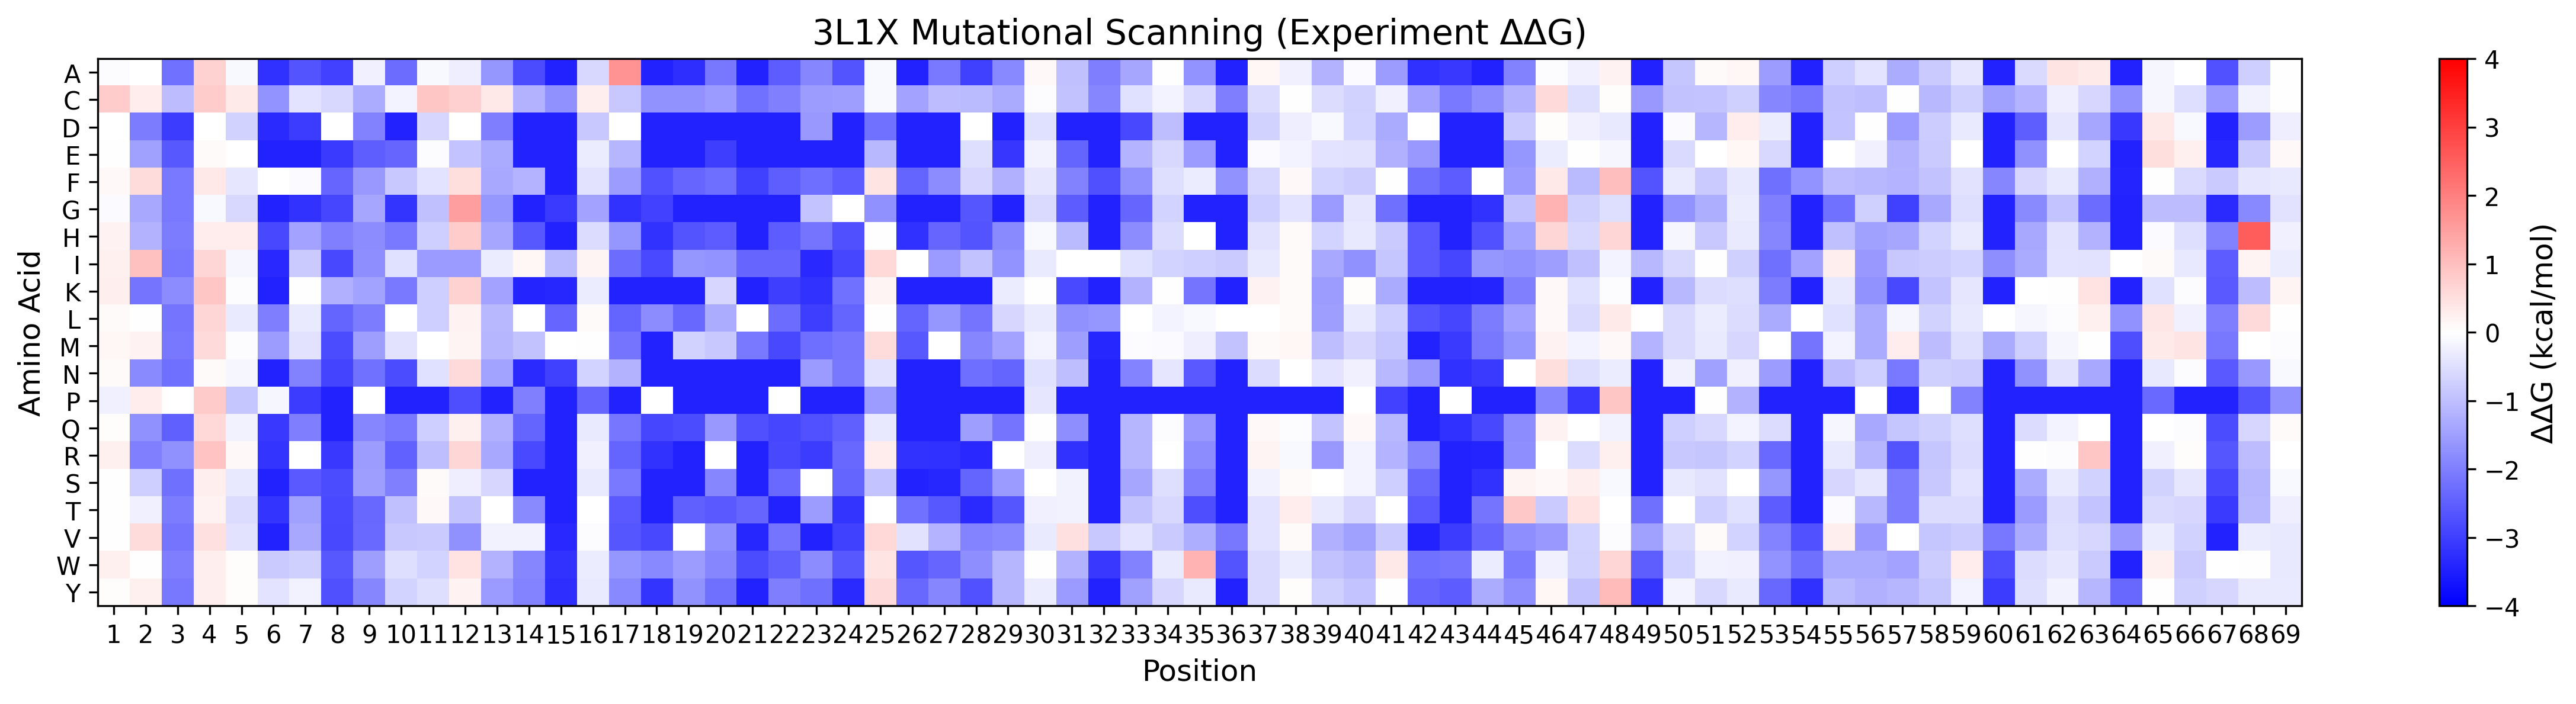

In [29]:
# Calculate the divergence as the maximum of the absolute values in the matrix
divergence = np.nanmax(np.abs(matrix_df.values))

plt.figure(figsize=(20, 4), dpi=300)
plt.imshow(matrix_df.T, cmap='bwr', interpolation='none', aspect='auto', vmin=-4, vmax=4)

cbar = plt.colorbar()

# Set the colorbar label with bold font
plt.xticks(ticks=np.arange(L), labels=positions)
plt.yticks(ticks=np.arange(20), labels=list(ALPHABET))
plt.xlabel('Position', fontsize=12)
plt.ylabel('Amino Acid', fontsize=12)
plt.xticks(ticks=np.arange(L), labels=np.arange(1, L + 1), fontdict={'fontsize': 10})
plt.yticks(ticks=range(len(ALPHABET)), labels=ALPHABET, fontdict={'fontsize': 10})
plt.title('3L1X Mutational Scanning (Experiment ΔΔG)', fontsize=14)
cbar.set_label('ΔΔG (kcal/mol)', fontsize=12)
plt.show()


## ESM3dG

In [39]:
cfg = get_default_config()
ddg_scanning = True 
cfg.testing.ddg_scanning = ddg_scanning

PDB_NAME = '3l1x'
CHAIN_ID = 'A'
WEIGHTS_DIR = "/home/jupyter-yehlin/ESM3_SaProt_dG/esm3dg_weights"
WEIGHT_FILES = [
    "esm3dg_weights/ESM3dG_weights_2_lora.ckpt",
]

pdb_path = '/home/jupyter-yehlin/ThermoMPNN/AlphaFold_model_PDBs/3L1X.pdb'
model = ESM3dG(WEIGHT_FILES[0], cfg)
pred_mutant_ddg, scaled_pred_mutant_ddg, combined_seq = ESM3dG_predict(model, pdb_path, CHAIN_ID, ddg_scanning)

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: read).
Your token has been saved to /home/jupyter-yehlin/.cache/huggingface/token
Login successful
freezing weights...
Running mutational scanning for sequence length 69...


/home/jupyter-yehlin/ESM3_SaProt_dG/ESM3dG.py:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sequence_tokens[i, :len(b['seq'])] = torch.tensor(b['seq'], dtype=torch.int32, device=device).clone().detach()
/home/jupyter-yehlin/ESM3_SaProt_dG/ESM3dG.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  structure_tokens[i, :len(b['struct'])] = torch.tensor(b['struct'], dtype=torch.int32, device=device).clone().detach()
/home/jupyter-yehlin/ESM3_SaProt_dG/ESM3dG.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  coordinates_tokens[i, :len(

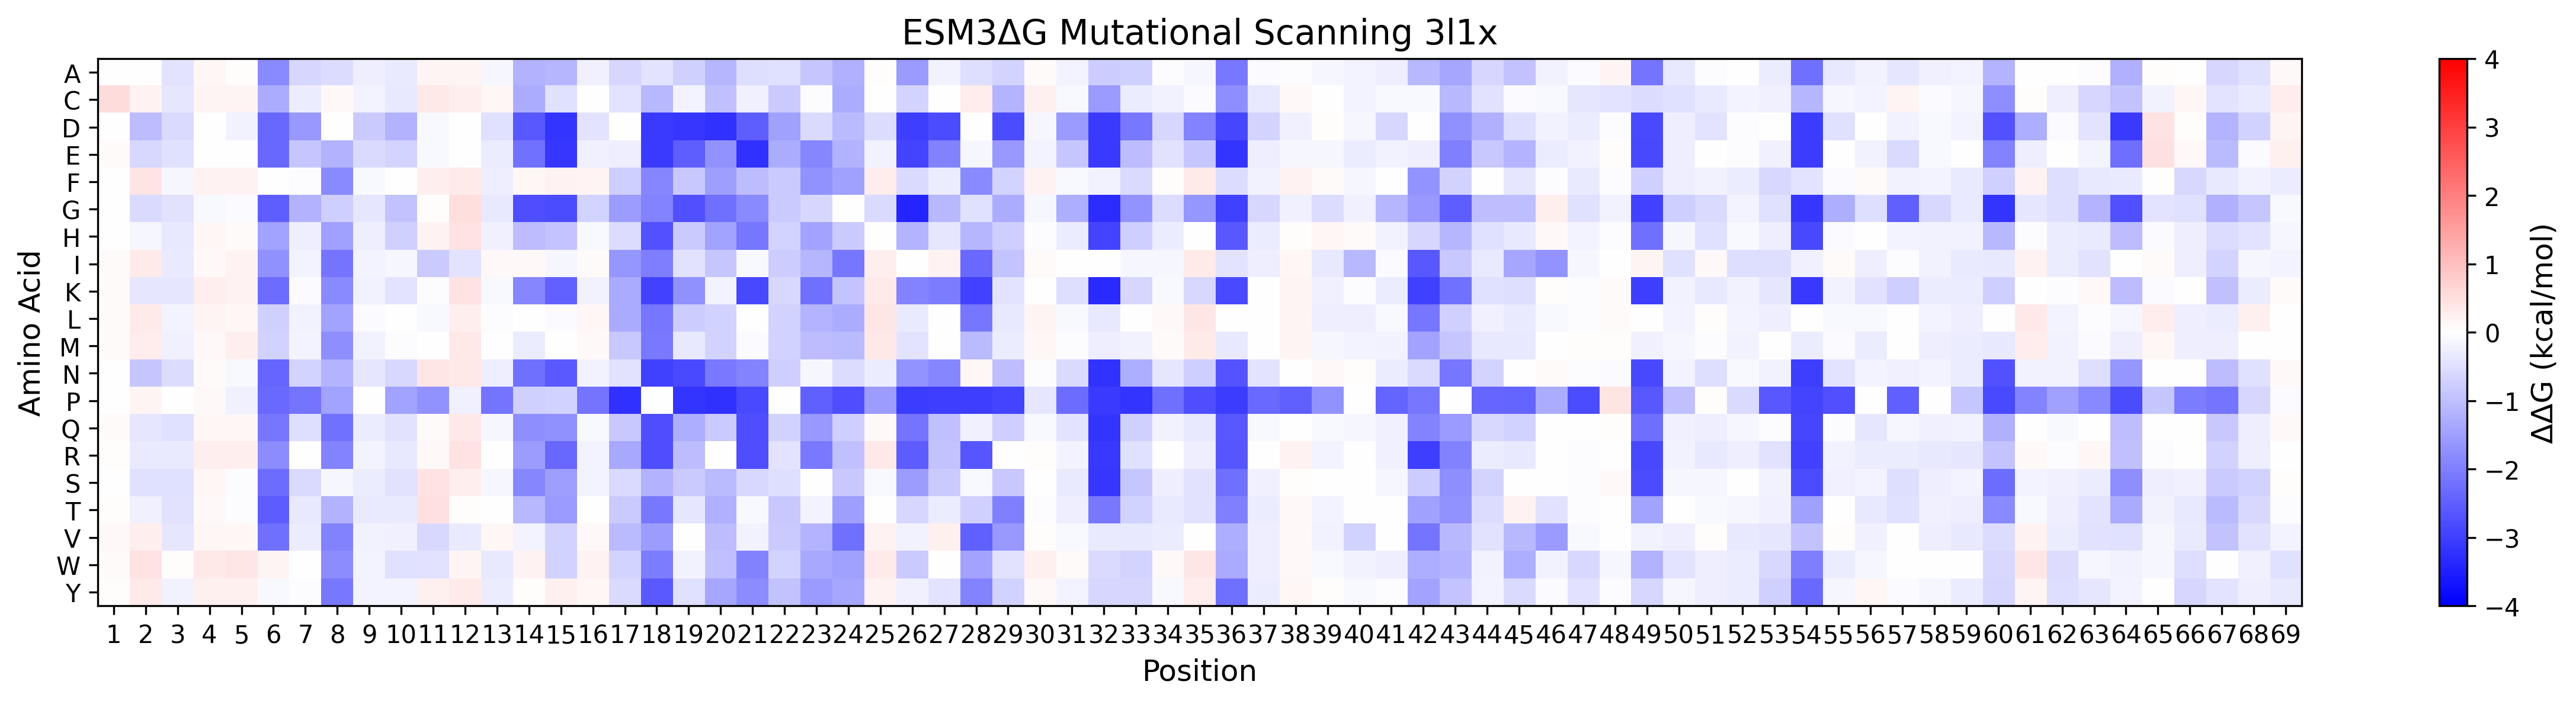

/tmp/ipykernel_2666272/1375885825.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  experiment_dg_flattened = torch.tensor(experiment_dg.flatten(), dtype=torch.float32)


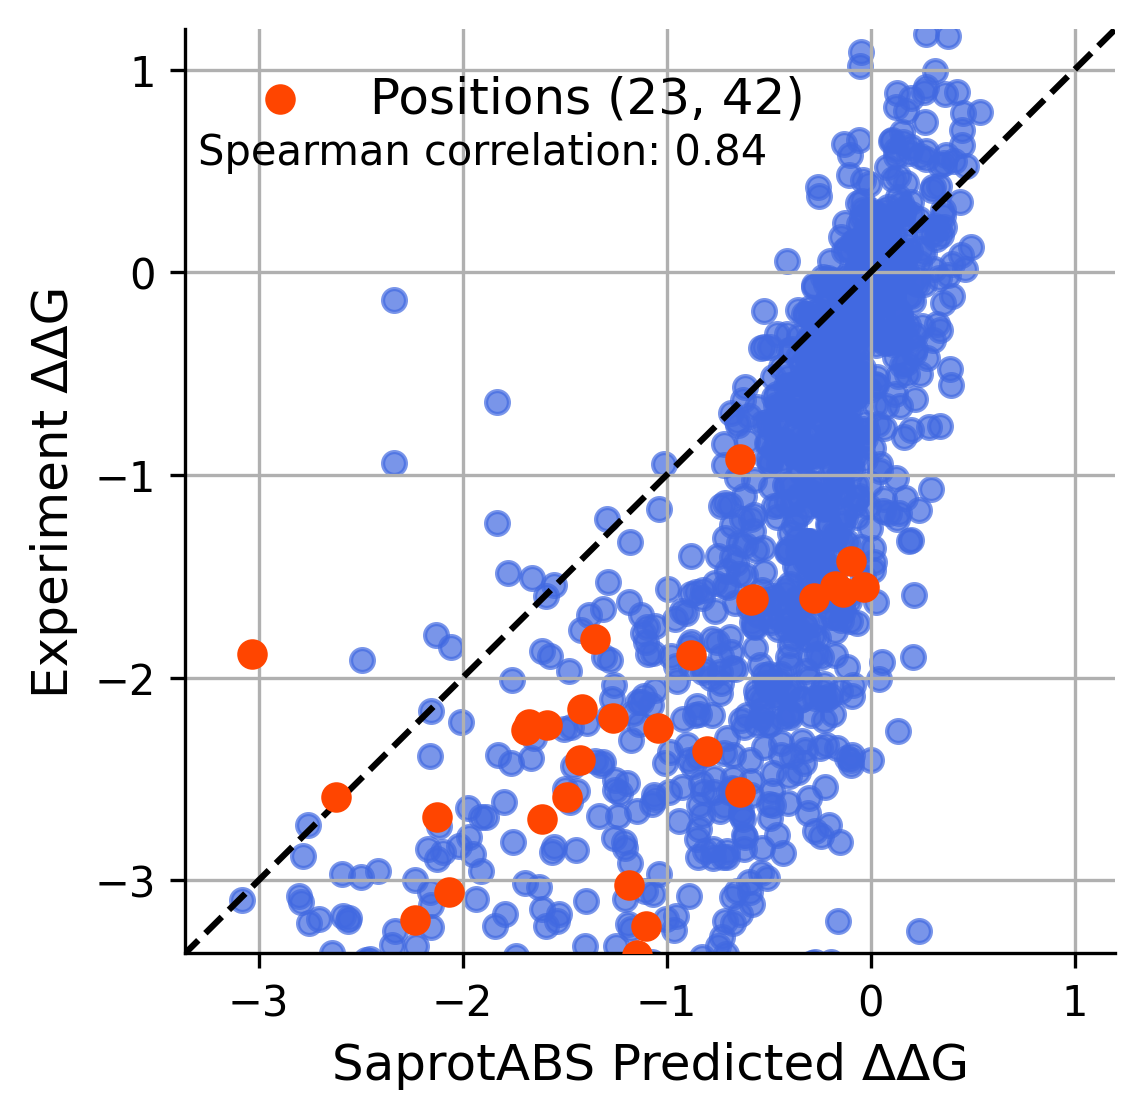

In [41]:

mean_results = np.mean(scaled_pred_mutant_ddg.detach().cpu().numpy(), axis=-1).T[0]

plt.figure(figsize=(20, 4), dpi=300)
plt.imshow(mean_results, cmap='bwr', interpolation='none', aspect='auto', vmin=-4, vmax=4)

cbar = plt.colorbar()

# Set the colorbar label with bold font
L = mean_results.shape[1]
plt.xticks(ticks=np.arange(L), labels=np.arange(1, L + 1), fontdict={'fontsize': 10})
plt.yticks(ticks=range(len(ALPHABET)), labels=ALPHABET, fontdict={'fontsize': 10})
plt.xlabel('Position', fontsize=12)
plt.ylabel('Amino Acid', fontsize=12)
plt.title("ESM3ΔG Mutational Scanning {}".format(PDB_NAME), fontsize=14)
cbar.set_label('ΔΔG (kcal/mol)', fontsize=12)
plt.show()
selected_columns = mean_results[:, [22, 41]]  # Shape will be [20, 2]

# Assuming matrix_df is defined and has shape [20, 69], and contains experimental values
experiment_dg = torch.tensor(matrix_df.T.values, dtype=torch.float32)  # Convert matrix_df to tensor

# Flatten the tensors for all points
experiment_dg_flattened = torch.tensor(experiment_dg.flatten(), dtype=torch.float32)
mean_results_flattened = torch.tensor(mean_results.flatten(), dtype=torch.float32)

# Create a valid mask based on experiment_dg
valid_mask = ~torch.isnan(experiment_dg_flattened) 

# Filter out NaNs from both experiment and mean results
filtered_mean_results = mean_results_flattened[valid_mask]
filtered_experiment_dg = experiment_dg_flattened[valid_mask]

# Get indices corresponding to columns 22 and 41
highlight_indices = [np.ravel_multi_index((i, col), mean_results.shape) for i in range(mean_results.shape[0]) for col in [22, 41]]
highlight_indices = torch.tensor(highlight_indices)

# Highlight only valid indices
highlight_valid_indices = valid_mask[highlight_indices]
highlight_selected_columns = mean_results_flattened[highlight_indices][highlight_valid_indices]
highlight_experiment_dg = experiment_dg_flattened[highlight_indices][highlight_valid_indices]

# Calculate Spearman correlation
spearman_corr, p_value = spearmanr(filtered_mean_results.numpy(), filtered_experiment_dg.numpy())

# Plotting
plt.figure(figsize=(4, 4), dpi = 300)

# Plot all points
plt.scatter(filtered_mean_results, filtered_experiment_dg, color='royalblue', s=30, alpha=0.7)

# Highlight the specific points in red
plt.scatter(highlight_selected_columns, highlight_experiment_dg, color='orangered', s=40, label="Positions (23, 42)", zorder=3)

# Add a diagonal line
plt.plot([-10, 3], [-10, 3], linestyle='--', color='black')
plt.text(0.32, 0.89, f'Spearman correlation: {spearman_corr:.2f}', 
         fontsize=10, ha='center', va='top', transform=plt.gca().transAxes)

plt.xlabel('SaprotABS Predicted ΔΔG', fontsize=12)
plt.ylabel('Experiment ΔΔG', fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim([min(filtered_experiment_dg)+0.1,1.2])  # Adjust based on your data
plt.ylim([min(filtered_experiment_dg)+0.1,1.2])  # Adjust based on your data

plt.grid()

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Show the plot
plt.legend(frameon=False, fontsize= 12)


## Augmented ESM3dG

In [33]:
cfg = get_default_config()
ddg_scanning = True 
cfg.testing.ddg_scanning = ddg_scanning

PDB_NAME = '3l1x'
CHAIN_ID = 'A'
WEIGHTS_DIR = "/home/jupyter-yehlin/ESM3_SaProt_dG/esm3dg_weights"
WEIGHT_FILES = [
    "esm3dg_weights/ESM3dG_weights_augmented_1_lora.ckpt",
]
pdb_path = '/home/jupyter-yehlin/ThermoMPNN/AlphaFold_model_PDBs/3L1X.pdb'
model = ESM3dG(WEIGHT_FILES[0], cfg)
pred_mutant_ddg, scaled_pred_mutant_ddg, combined_seq = ESM3dG_predict(model, pdb_path, CHAIN_ID, ddg_scanning)

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: read).
Your token has been saved to /home/jupyter-yehlin/.cache/huggingface/token
Login successful
freezing weights...
Running mutational scanning for sequence length 69...


/home/jupyter-yehlin/ESM3_SaProt_dG/ESM3dG.py:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sequence_tokens[i, :len(b['seq'])] = torch.tensor(b['seq'], dtype=torch.int32, device=device).clone().detach()
/home/jupyter-yehlin/ESM3_SaProt_dG/ESM3dG.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  structure_tokens[i, :len(b['struct'])] = torch.tensor(b['struct'], dtype=torch.int32, device=device).clone().detach()
/home/jupyter-yehlin/ESM3_SaProt_dG/ESM3dG.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  coordinates_tokens[i, :len(

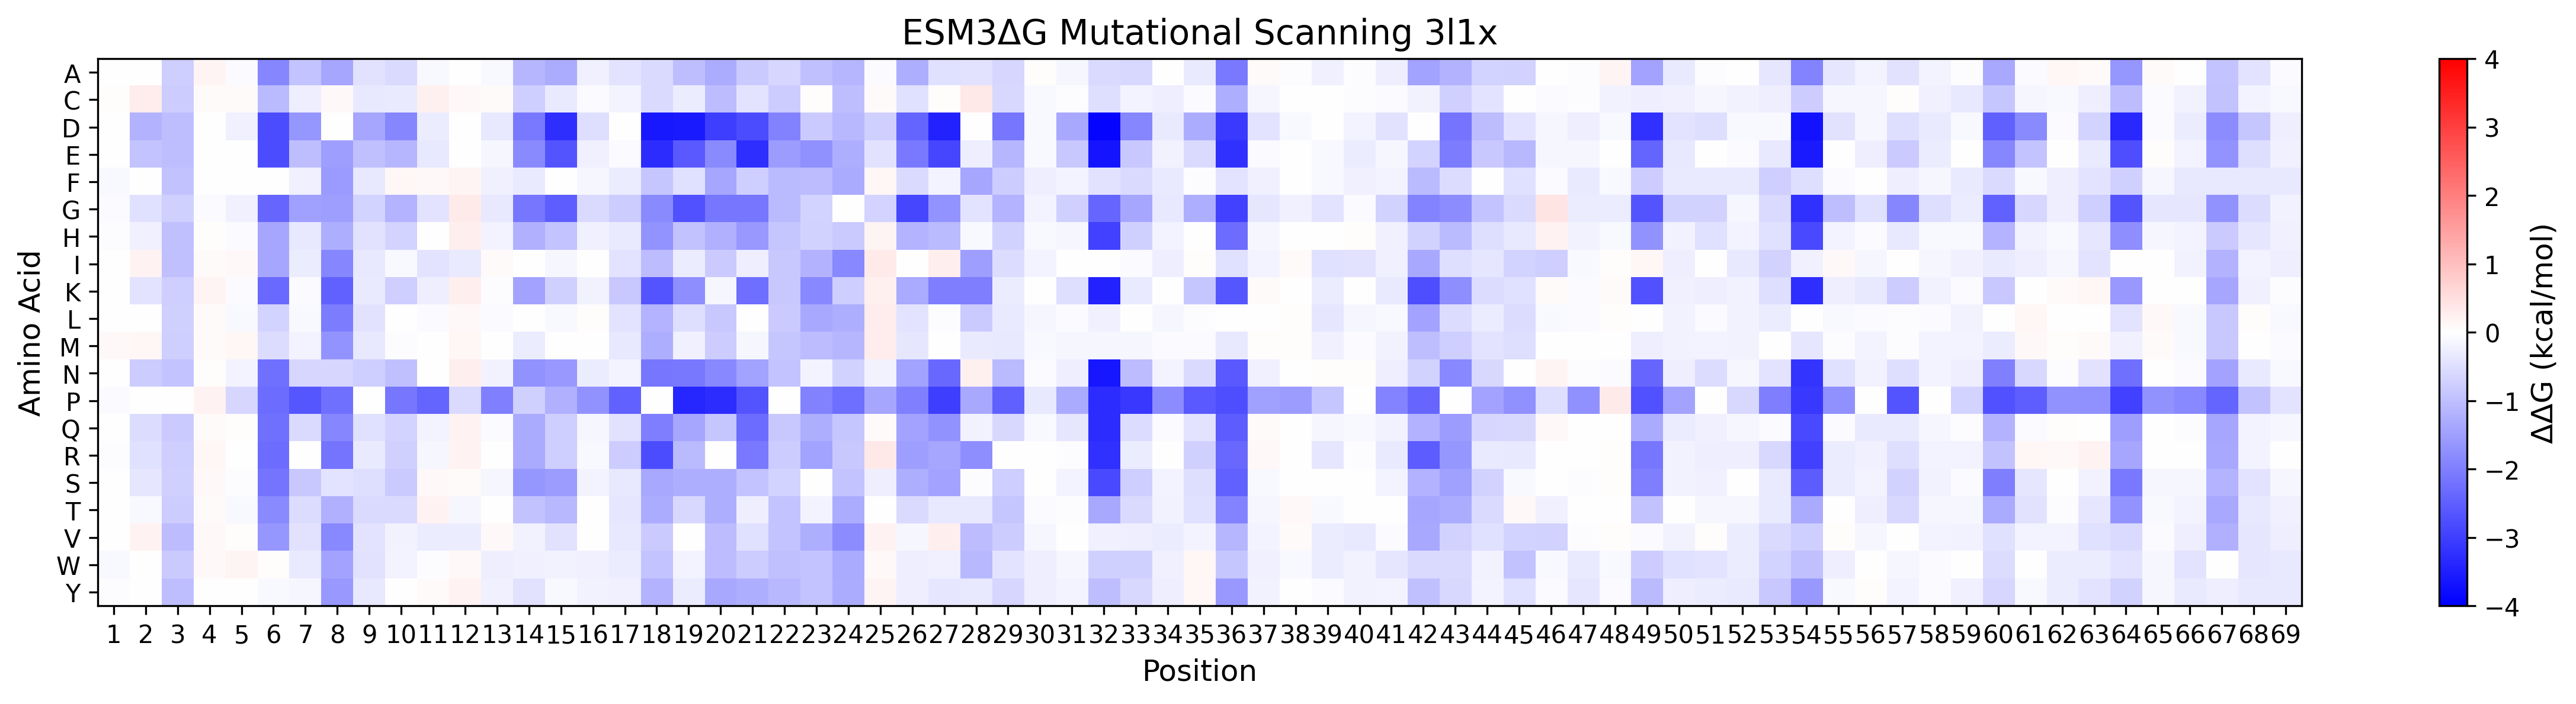

/tmp/ipykernel_2666272/2943142073.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  experiment_dg_flattened = torch.tensor(experiment_dg.flatten(), dtype=torch.float32)


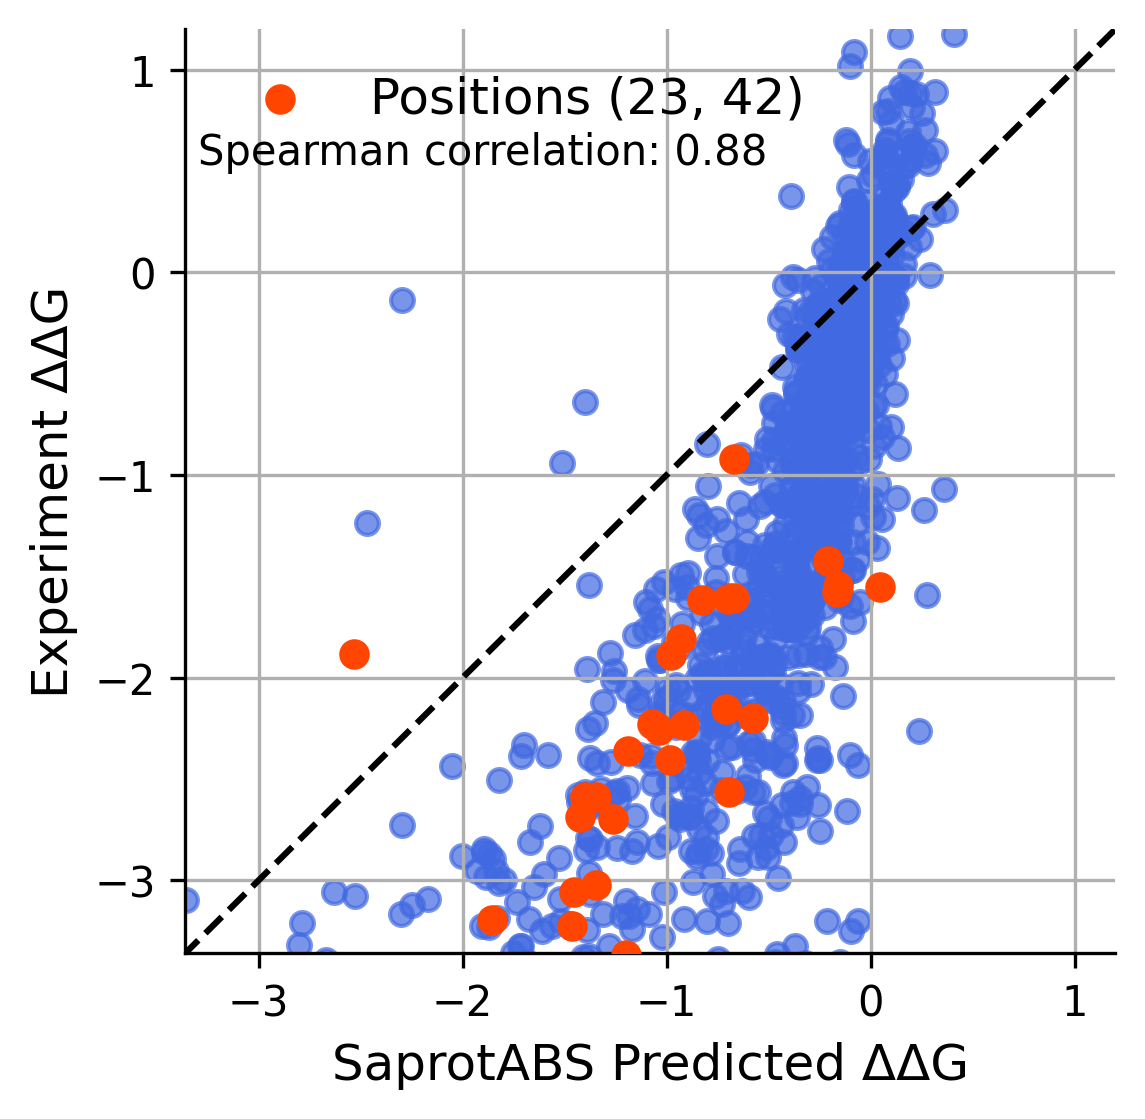

In [35]:

mean_results = np.mean(scaled_pred_mutant_ddg.detach().cpu().numpy(), axis=-1).T[0]

plt.figure(figsize=(20, 4), dpi=300)
plt.imshow(mean_results, cmap='bwr', interpolation='none', aspect='auto', vmin=-4, vmax=4)

cbar = plt.colorbar()

# Set the colorbar label with bold font
L = mean_results.shape[1]
plt.xticks(ticks=np.arange(L), labels=np.arange(1, L + 1), fontdict={'fontsize': 10})
plt.yticks(ticks=range(len(ALPHABET)), labels=ALPHABET, fontdict={'fontsize': 10})
plt.xlabel('Position', fontsize=12)
plt.ylabel('Amino Acid', fontsize=12)
plt.title("ESM3ΔG Mutational Scanning {}".format(PDB_NAME), fontsize=14)
cbar.set_label('ΔΔG (kcal/mol)', fontsize=12)
plt.show()

# Select the columns 22 and 41 from all rows

selected_columns = mean_results[:, [22, 41]]  # Shape will be [20, 2]

# Assuming matrix_df is defined and has shape [20, 69], and contains experimental values
experiment_dg = torch.tensor(matrix_df.T.values, dtype=torch.float32)  # Convert matrix_df to tensor

# Flatten the tensors for all points
experiment_dg_flattened = torch.tensor(experiment_dg.flatten(), dtype=torch.float32)
mean_results_flattened = torch.tensor(mean_results.flatten(), dtype=torch.float32)

# Create a valid mask based on experiment_dg
valid_mask = ~torch.isnan(experiment_dg_flattened) 

# Filter out NaNs from both experiment and mean results
filtered_mean_results = mean_results_flattened[valid_mask]
filtered_experiment_dg = experiment_dg_flattened[valid_mask]

# Get indices corresponding to columns 22 and 41
highlight_indices = [np.ravel_multi_index((i, col), mean_results.shape) for i in range(mean_results.shape[0]) for col in [22, 41]]
highlight_indices = torch.tensor(highlight_indices)

# Highlight only valid indices
highlight_valid_indices = valid_mask[highlight_indices]
highlight_selected_columns = mean_results_flattened[highlight_indices][highlight_valid_indices]
highlight_experiment_dg = experiment_dg_flattened[highlight_indices][highlight_valid_indices]

# Calculate Spearman correlation
spearman_corr, p_value = spearmanr(filtered_mean_results.numpy(), filtered_experiment_dg.numpy())

# Plotting
plt.figure(figsize=(4, 4), dpi = 300)

# Plot all points
plt.scatter(filtered_mean_results, filtered_experiment_dg, color='royalblue', s=30, alpha=0.7)

# Highlight the specific points in red
plt.scatter(highlight_selected_columns, highlight_experiment_dg, color='orangered', s=40, label="Positions (23, 42)", zorder=3)

# Add a diagonal line
plt.plot([-10, 3], [-10, 3], linestyle='--', color='black')
plt.text(0.32, 0.89, f'Spearman correlation: {spearman_corr:.2f}', 
         fontsize=10, ha='center', va='top', transform=plt.gca().transAxes)

plt.xlabel('SaprotABS Predicted ΔΔG', fontsize=12)
plt.ylabel('Experiment ΔΔG', fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim([min(filtered_experiment_dg)+0.1,1.2])  # Adjust based on your data
plt.ylim([min(filtered_experiment_dg)+0.1,1.2])  # Adjust based on your data

plt.grid()

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Show the plot
plt.legend(frameon=False, fontsize= 12)


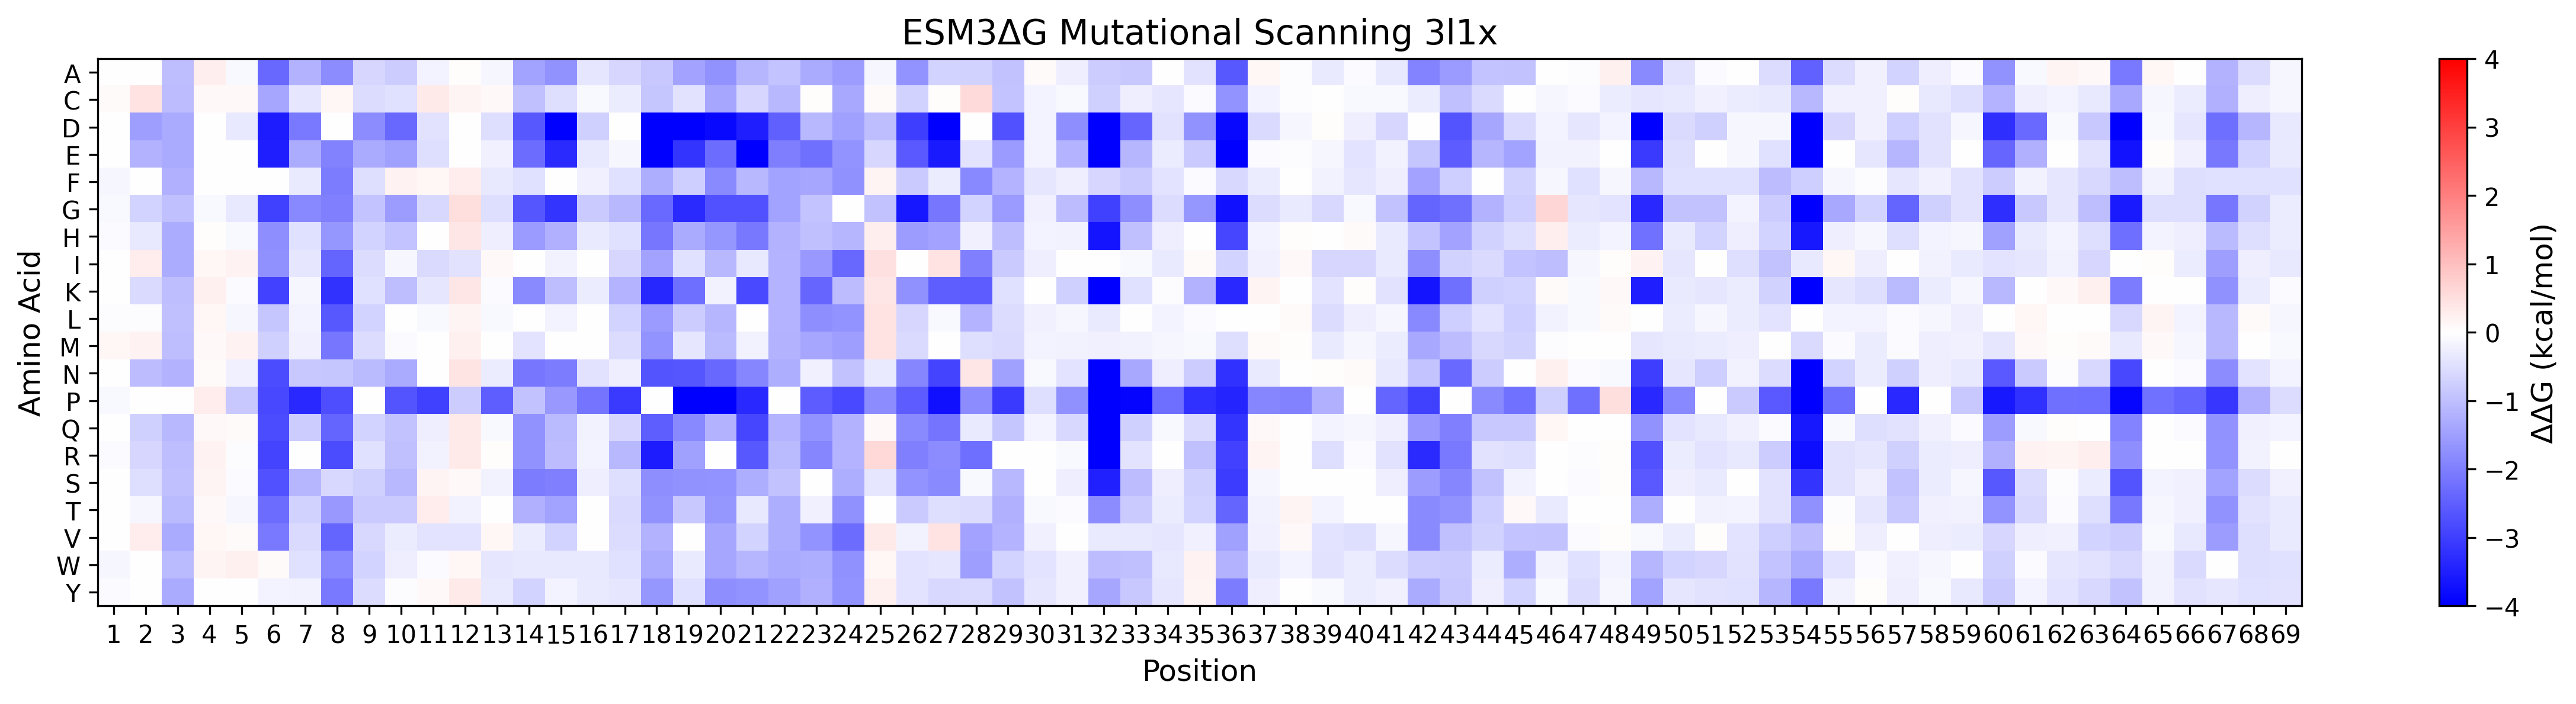

/tmp/ipykernel_2666272/4119331443.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  experiment_dg_flattened = torch.tensor(experiment_dg.flatten(), dtype=torch.float32)


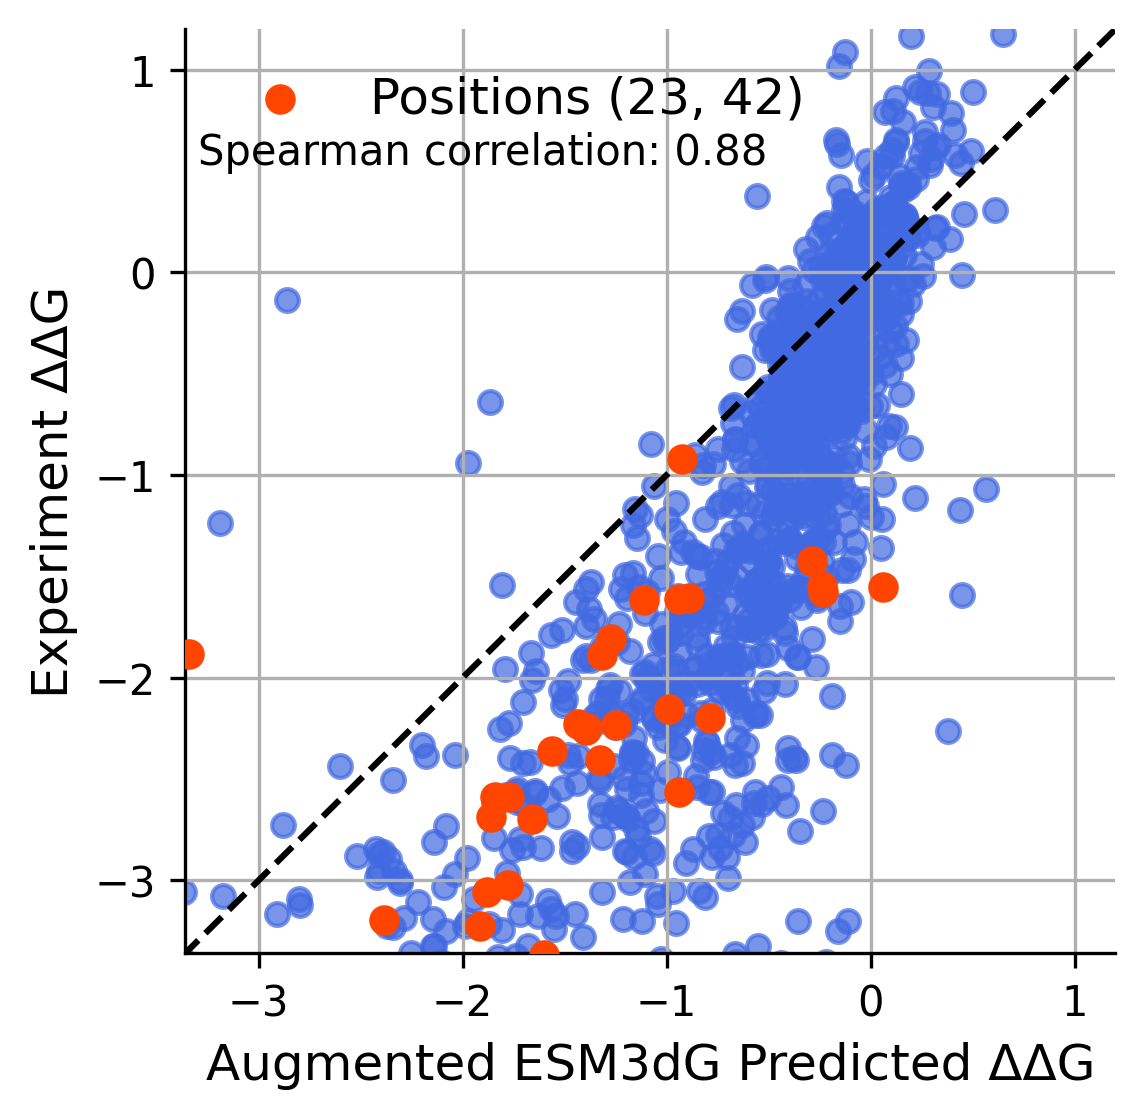

In [38]:

mean_results = np.mean(pred_mutant_ddg.detach().cpu().numpy(), axis=-1).T[0]

plt.figure(figsize=(20, 4), dpi=300)
plt.imshow(mean_results, cmap='bwr', interpolation='none', aspect='auto', vmin=-4, vmax=4)

cbar = plt.colorbar()

# Set the colorbar label with bold font
L = mean_results.shape[1]
plt.xticks(ticks=np.arange(L), labels=np.arange(1, L + 1), fontdict={'fontsize': 10})
plt.yticks(ticks=range(len(ALPHABET)), labels=ALPHABET, fontdict={'fontsize': 10})
plt.xlabel('Position', fontsize=12)
plt.ylabel('Amino Acid', fontsize=12)
plt.title("ESM3ΔG Mutational Scanning {}".format(PDB_NAME), fontsize=14)
cbar.set_label('ΔΔG (kcal/mol)', fontsize=12)
plt.show()

# Select the columns 22 and 41 from all rows

selected_columns = mean_results[:, [22, 41]]  # Shape will be [20, 2]

# Assuming matrix_df is defined and has shape [20, 69], and contains experimental values
experiment_dg = torch.tensor(matrix_df.T.values, dtype=torch.float32)  # Convert matrix_df to tensor

# Flatten the tensors for all points
experiment_dg_flattened = torch.tensor(experiment_dg.flatten(), dtype=torch.float32)
mean_results_flattened = torch.tensor(mean_results.flatten(), dtype=torch.float32)

# Create a valid mask based on experiment_dg
valid_mask = ~torch.isnan(experiment_dg_flattened) 

# Filter out NaNs from both experiment and mean results
filtered_mean_results = mean_results_flattened[valid_mask]
filtered_experiment_dg = experiment_dg_flattened[valid_mask]

# Get indices corresponding to columns 22 and 41
highlight_indices = [np.ravel_multi_index((i, col), mean_results.shape) for i in range(mean_results.shape[0]) for col in [22, 41]]
highlight_indices = torch.tensor(highlight_indices)

# Highlight only valid indices
highlight_valid_indices = valid_mask[highlight_indices]
highlight_selected_columns = mean_results_flattened[highlight_indices][highlight_valid_indices]
highlight_experiment_dg = experiment_dg_flattened[highlight_indices][highlight_valid_indices]

# Calculate Spearman correlation
spearman_corr, p_value = spearmanr(filtered_mean_results.numpy(), filtered_experiment_dg.numpy())

# Plotting
plt.figure(figsize=(4, 4), dpi = 300)

# Plot all points
plt.scatter(filtered_mean_results, filtered_experiment_dg, color='royalblue', s=30, alpha=0.7)

# Highlight the specific points in red
plt.scatter(highlight_selected_columns, highlight_experiment_dg, color='orangered', s=40, label="Positions (23, 42)", zorder=3)

# Add a diagonal line
plt.plot([-10, 3], [-10, 3], linestyle='--', color='black')
plt.text(0.32, 0.89, f'Spearman correlation: {spearman_corr:.2f}', 
         fontsize=10, ha='center', va='top', transform=plt.gca().transAxes)

plt.xlabel('Augmented ESM3dG Predicted ΔΔG', fontsize=12)
plt.ylabel('Experiment ΔΔG', fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim([min(filtered_experiment_dg)+0.1,1.2])  # Adjust based on your data
plt.ylim([min(filtered_experiment_dg)+0.1,1.2])  # Adjust based on your data

plt.grid()

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Show the plot
plt.legend(frameon=False, fontsize= 12)


## Saprot

In [42]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import WandbLogger
from torchmetrics import MeanSquaredError, R2Score, SpearmanCorrCoef, PearsonCorrCoef
from omegaconf import OmegaConf

from utils.foldseek_util import get_struc_seq
import torch
from torch.utils.data import ConcatDataset
import pandas as pd
import numpy as np
import pickle

from Bio import pairwise2
from math import isnan
from tqdm import tqdm
from dataclasses import dataclass
from typing import Optional
from torch.utils.data import ConcatDataset
import numpy as np
import matplotlib.pyplot as plt


ALPHABET = 'ACDEFGHIKLMNPQRSTVWY-'
from config import get_default_config, get_model_configs
from SaProtABS import SaProtABS, SaProtABS_predict

import logging
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)


/home/jupyter-yehlin/.conda/envs/esm3_attention/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [43]:
cfg = get_default_config()
ddg_scanning = True 
cfg.testing.ddg_scanning = ddg_scanning

PDB_NAME = '1lze'
CHAIN_ID = 'A'
WEIGHTS_DIR = "/home/jupyter-yehlin/ESM3_SaProt_dG/saprotdg_weights"
WEIGHT_FILES = [
    "saprotdg_weights/SaProtdG_weights_1_lora.ckpt",
]

pdb_path = '/home/jupyter-yehlin/ThermoMPNN/AlphaFold_model_PDBs/3L1X.pdb'
model = SaProtdG(WEIGHT_FILES[0],cfg)
pred_mutant_ddg, scaled_pred_mutant_ddg, combined_seq = SaProtdG_predict(model, pdb_path, CHAIN_ID, ddg_scanning)

Loading base SaProt model from transformers...


Some weights of EsmForMaskedLM were not initialized from the model checkpoint at westlake-repl/SaProt_650M_AF2 and are newly initialized: ['esm.contact_head.regression.bias', 'esm.contact_head.regression.weight', 'esm.embeddings.position_embeddings.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Applying LoRA to base model...


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


mutational scanning


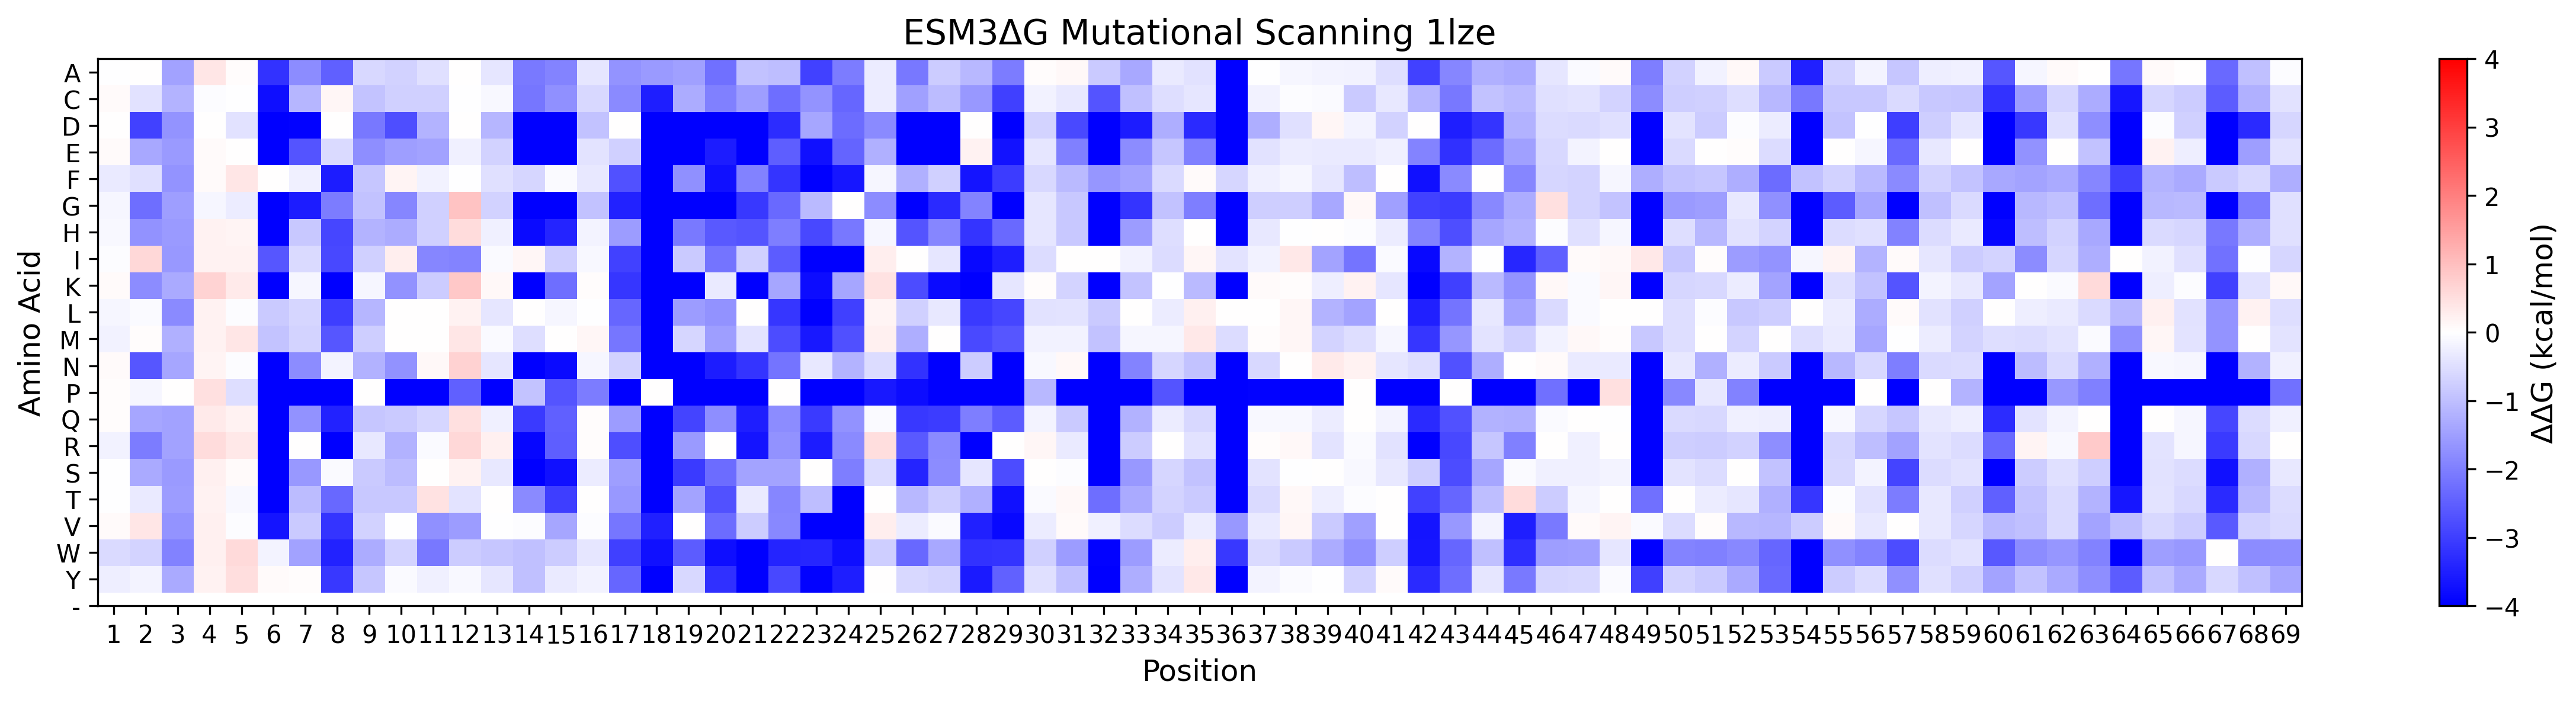

/tmp/ipykernel_2666272/2672514641.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  experiment_dg_flattened = torch.tensor(experiment_dg.flatten(), dtype=torch.float32)


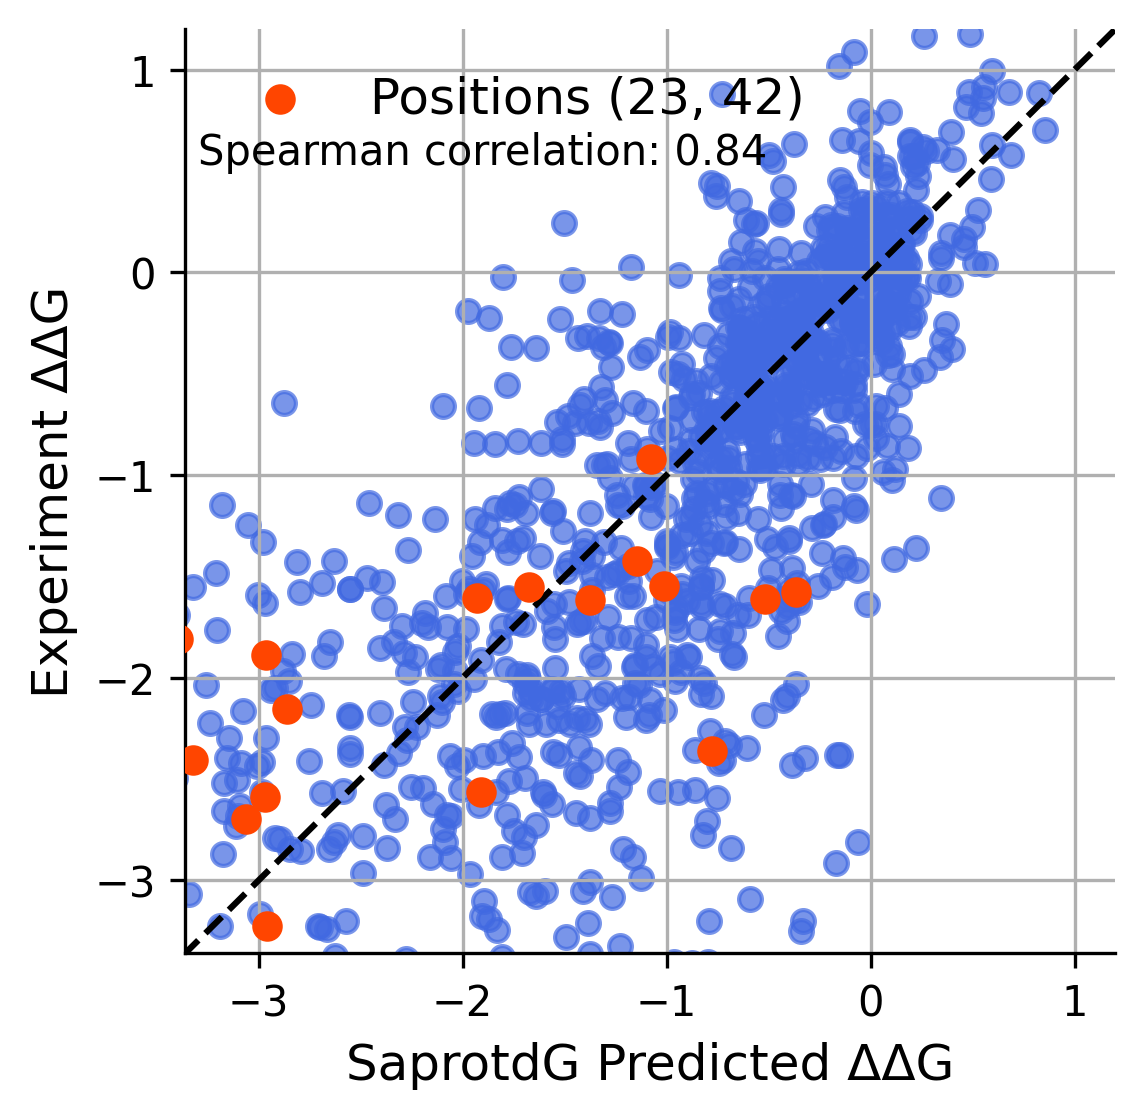

In [45]:

mean_results = np.mean(pred_mutant_ddg.detach().cpu().numpy(), axis=-1).T[0]

plt.figure(figsize=(20, 4), dpi=300)
plt.imshow(mean_results, cmap='bwr', interpolation='none', aspect='auto', vmin=-4, vmax=4)

cbar = plt.colorbar()

# Set the colorbar label with bold font
L = mean_results.shape[1]
plt.xticks(ticks=np.arange(L), labels=np.arange(1, L + 1), fontdict={'fontsize': 10})
plt.yticks(ticks=range(len(ALPHABET)), labels=ALPHABET, fontdict={'fontsize': 10})
plt.xlabel('Position', fontsize=12)
plt.ylabel('Amino Acid', fontsize=12)
plt.title("ESM3ΔG Mutational Scanning {}".format(PDB_NAME), fontsize=14)
cbar.set_label('ΔΔG (kcal/mol)', fontsize=12)
plt.show()

# Select the columns 22 and 41 from all rows

selected_columns = mean_results[:, [22, 41]]  # Shape will be [20, 2]

# Assuming matrix_df is defined and has shape [20, 69], and contains experimental values
experiment_dg = torch.tensor(matrix_df.T.values, dtype=torch.float32)  # Convert matrix_df to tensor

# Flatten the tensors for all points
experiment_dg_flattened = torch.tensor(experiment_dg.flatten(), dtype=torch.float32)
mean_results_flattened = torch.tensor(mean_results.flatten(), dtype=torch.float32)

# Create a valid mask based on experiment_dg
valid_mask = ~torch.isnan(experiment_dg_flattened) 

# Filter out NaNs from both experiment and mean results
filtered_mean_results = mean_results_flattened[valid_mask]
filtered_experiment_dg = experiment_dg_flattened[valid_mask]

# Get indices corresponding to columns 22 and 41
highlight_indices = [np.ravel_multi_index((i, col), mean_results.shape) for i in range(mean_results.shape[0]) for col in [22, 41]]
highlight_indices = torch.tensor(highlight_indices)

# Highlight only valid indices
highlight_valid_indices = valid_mask[highlight_indices]
highlight_selected_columns = mean_results_flattened[highlight_indices][highlight_valid_indices]
highlight_experiment_dg = experiment_dg_flattened[highlight_indices][highlight_valid_indices]

# Calculate Spearman correlation
spearman_corr, p_value = spearmanr(filtered_mean_results.numpy(), filtered_experiment_dg.numpy())

# Plotting
plt.figure(figsize=(4, 4), dpi = 300)

# Plot all points
plt.scatter(filtered_mean_results, filtered_experiment_dg, color='royalblue', s=30, alpha=0.7)

# Highlight the specific points in red
plt.scatter(highlight_selected_columns, highlight_experiment_dg, color='orangered', s=40, label="Positions (23, 42)", zorder=3)

# Add a diagonal line
plt.plot([-10, 3], [-10, 3], linestyle='--', color='black')
plt.text(0.32, 0.89, f'Spearman correlation: {spearman_corr:.2f}', 
         fontsize=10, ha='center', va='top', transform=plt.gca().transAxes)

plt.xlabel('SaprotdG Predicted ΔΔG', fontsize=12)
plt.ylabel('Experiment ΔΔG', fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim([min(filtered_experiment_dg)+0.1,1.2])  # Adjust based on your data
plt.ylim([min(filtered_experiment_dg)+0.1,1.2])  # Adjust based on your data

plt.grid()

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Show the plot
plt.legend(frameon=False, fontsize= 12)